# CNN으로 MNIST 분류하기

1) 합성곱 + 활성화 함수를 하나아ㅢ 합성곱 층오로 보고, 맥스풀링은 별도의 풀링 층으로 보기.
2) 합성곱 + 활성화 함수 + 맥스풀링을 하나의 합성곱으로 본다

두가지 방법이 있는데, 일단 두번째 방법을 택한다.

1번 레이어 - Convolutional Layer  
합성곱 : (입력채널=1, 출력채널=32, 커널사이즈=3, 스트라이드=1, 패딩=1) + ReLU  
맥스풀링 : (커널사이즈=2, 스트라이드=2)  

2번 레이어 - Convolutional Layer   
합성곱 : (입력채널=32, 출력채널=36, 커널사이즈=3, 스트라이드=1, 패딩=1) + ReLU  
맥스풀링 : (커널사이즈=2, 스트라이드=2)  

3번 레이어 - Fully-Connected Layer  
특성맵을 펼친다.  
전결합층(뉴런 10개) + Softmax  

## 이론

In [1]:
import torch
import torch.nn as nn

In [2]:
inputs = torch.Tensor(1, 1, 28, 28) # batch_size, channels, height, width
print("텐서의 크기:", inputs.shape)

텐서의 크기: torch.Size([1, 1, 28, 28])


In [3]:
conv1 = nn.Conv2d(1, 32, 3, padding=1) # in_channels, out_channels, kernel_size, padding
print(conv1)

Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [4]:
conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
print(conv2)

Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [5]:
pool = nn.MaxPool2d(2, 2) # kernel_size, stride
print(pool)

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [6]:
out = conv1(inputs)
print("Conv1 출력 크기:", out.shape)

Conv1 출력 크기: torch.Size([1, 32, 28, 28])


In [7]:
out = pool(out)
print("MaxPool 출력 크기:", out.shape)

MaxPool 출력 크기: torch.Size([1, 32, 14, 14])


In [8]:
out = conv2(out)
print("Conv2 출력 크기:", out.shape)

Conv2 출력 크기: torch.Size([1, 64, 14, 14])


In [9]:
out = pool(out)
print("최종 출력 크기:", out.shape)

최종 출력 크기: torch.Size([1, 64, 7, 7])


In [10]:
# 배치 차원은 유지한채 나머지를 전부 하나의 차원으로 펼쳐줍니다.
out = out.view(out.size(0), -1) # batch_size, features
print(out.shape)

torch.Size([1, 3136])


In [11]:
fc = nn.Linear(3136, 10) # in_put_dim = 3,136, out_put_dim = 10
out = fc(out)
print("최종 출력 크기:", out.shape)

최종 출력 크기: torch.Size([1, 10])


## CNN으로 MNIST분류하기

In [12]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.init

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)

if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [14]:
learning_rate = 0.001
training_epochs = 15
batch_size = 100

In [15]:
mnist_train = datasets.MNIST(root='MNIST_data/',
                             train=True,
                             transform=transforms.ToTensor(),
                             download=True)

mnist_test = datasets.MNIST(root='MNIST_data/',
                            train=False,
                            transform=transforms.ToTensor(),
                            download=True)


data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.50MB/s]


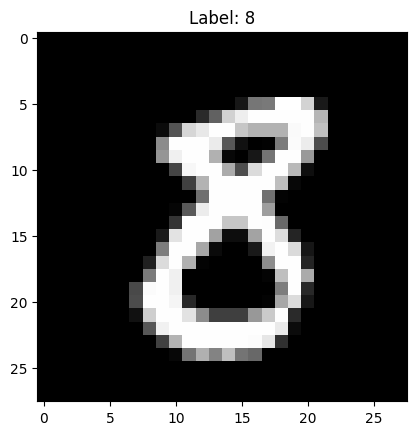

In [16]:
#학습 이미지 랜덤 표시
import random
import matplotlib.pyplot as plt

# 무작위 인덱스 선택
index = random.randint(0, len(mnist_train) - 1)
# 이미지와 레이블 가져오기
image, label = mnist_train[index]
# 텐서를 numpy로 변환 (채널 차원 제거)
image = image.squeeze().numpy()
# 이미지 표시
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [17]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Linear(7 * 7 * 64, 10, bias=True)

        torch.nn.init.xavier_uniform_(self.fc.weight) #자비에르 균등 초기화

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [18]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [19]:
total_batch = len(data_loader)
print('총 배치의 수 : {}'.format(total_batch))

총 배치의 수 : 600


In [20]:
for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader:
        X = X.to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch #미니배치로 나눴으니까 평균 비용 계산

    print('Epoch: {:04d}, Cost: {:.9f}'.format(epoch + 1, avg_cost))

Epoch: 0001, Cost: 0.225598752
Epoch: 0002, Cost: 0.062477175
Epoch: 0003, Cost: 0.045287699
Epoch: 0004, Cost: 0.036463160
Epoch: 0005, Cost: 0.030318558
Epoch: 0006, Cost: 0.025147000
Epoch: 0007, Cost: 0.021466639
Epoch: 0008, Cost: 0.017732466
Epoch: 0009, Cost: 0.016126567
Epoch: 0010, Cost: 0.012766995
Epoch: 0011, Cost: 0.009919703
Epoch: 0012, Cost: 0.009558409
Epoch: 0013, Cost: 0.007999651
Epoch: 0014, Cost: 0.007092782
Epoch: 0015, Cost: 0.006331584


In [22]:
with torch.no_grad():
    X_test = mnist_test.test_data.view(len(mnist_test), 1, 28, 28).float().to(device)
    Y_test = mnist_test.test_labels.to(device)

    prediction = model(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean()
    print('Accuracy: {:.4f}'.format(accuracy.item()))

Accuracy: 0.9865
